In [4]:
import pickle
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parent))
from viz_style import apply_style
apply_style()

import MixedEffectsModeling.config as config
from MixedEffectsModeling.core.model_engine_mixed import NormativeModelEngineMixed
from MixedEffectsModeling.core.ood_filter import MahalanobisFilter, RangeFilter
from MixedEffectsModeling.core.shash import load_shash_params, shash_correct_matrix
from MixedEffectsModeling.validation.lobo_engine import load_full_data

ZDIR = Path('./Z_scores_mixed')
ZDIR.mkdir(parents=True, exist_ok=True)

In [5]:
# 0. Load production engine + disease covariates/counts (non-HC rows of the same QC-filtered cohort LOBO uses)
engine = NormativeModelEngineMixed.load(config.ENGINE_MIXED_DIR)
gene_names = [g for g in engine.genes if engine.genes[g].ok]

data = load_full_data()
dis_idx = np.where(~data['is_hc'])[0]
X_dis = data['X_raw'][dis_idx]
Y_dis = data['Y'][dis_idx][:, [data['gene_col'][g] for g in gene_names]]
names_dis = data['names'][dis_idx]
batch_dis = data['batch'][dis_idx]
phenotype_dis = data['phenotype'][dis_idx]

print(f"engine genes (ok): {len(gene_names)}")
print(f"disease samples: {len(dis_idx)}")
print(pd.Series(phenotype_dis).value_counts())

engine genes (ok): 19858
disease samples: 913
CAD_HF+               116
CAD_HF-               108
Tuberculosis          103
ME/CFS                 90
Pancreatitis           81
Pancreatic Cancer      74
Pre-eclampsia          62
Liver Cancer           48
Colorectal Cancer      41
Lung Cancer            33
Stomach Cancer         29
Esophagus Cancer       27
MM                     18
Other Cancer           18
HIV                    13
HIV + Tuberculosis     11
ICI-m                  11
ICI-treated Cancer     11
MGUS                    8
Pancreatic Cancer       6
Liver Cirrhosis         5
Name: count, dtype: int64


In [6]:
hc_train_mask = data['is_hc'] & ~np.isin(data['batch'], list(data['small_hc_batches']))
X_hc = data['X_raw'][hc_train_mask]

ood = MahalanobisFilter(percentile=95).fit(X_hc)
mahal_dist = ood.distances(X_dis)
mahal_keep = mahal_dist <= ood.threshold_
rng_filter = RangeFilter(n_out_thr=2).fit(X_hc)
n_out = rng_filter.n_out(X_dis)
range_keep = rng_filter.mask(X_dis)

ood_keep = mahal_keep & range_keep

summary = (pd.DataFrame({'phenotype': phenotype_dis, 'keep': ood_keep})
          .groupby('phenotype')['keep']
          .agg(n_total='size', n_kept='sum')
          .assign(pct_removed=lambda d: (1 - d['n_kept'] / d['n_total']) * 100)
          .sort_values('pct_removed', ascending=False))
print(f"Mahalanobis P95 threshold: {ood.threshold_:.2f}  (flagged {int((~mahal_keep).sum())})")
print(f"Range filter (>={rng_filter.n_out_thr} axes outside HC p1-p99): flagged {int((~range_keep).sum())}")
print(f"combined: kept {ood_keep.sum()}/{len(ood_keep)} ({(~ood_keep).mean()*100:.1f}% flagged OOD)")
print(summary.to_string())

Mahalanobis P95 threshold: 5.21  (flagged 50)
Range filter (>=2 axes outside HC p1-p99): flagged 54
combined: kept 833/913 (8.8% flagged OOD)
                    n_total  n_kept  pct_removed
phenotype                                       
Pancreatic Cancer         6       2    66.666667
Stomach Cancer           29      21    27.586207
Lung Cancer              33      26    21.212121
Liver Cirrhosis           5       4    20.000000
ICI-treated Cancer       11       9    18.181818
Colorectal Cancer        41      34    17.073171
Liver Cancer             48      40    16.666667
CAD_HF+                 116     101    12.931034
Other Cancer             18      16    11.111111
CAD_HF-                 108      97    10.185185
HIV + Tuberculosis       11      10     9.090909
ICI-m                    11      10     9.090909
Esophagus Cancer         27      25     7.407407
Pre-eclampsia            62      58     6.451613
MM                       18      17     5.555556
Pancreatic Cancer        

In [7]:
%matplotlib inline

21 phenotypes, 913 disease samples scored
                    n_total  n_kept
phenotype                          
Pancreatic Cancer         6       2
Stomach Cancer           29      21
Lung Cancer              33      26
Liver Cirrhosis           5       4
ICI-treated Cancer       11       9
Colorectal Cancer        41      34
Liver Cancer             48      40
CAD_HF+                 116     101
Other Cancer             18      16
CAD_HF-                 108      97
HIV + Tuberculosis       11      10
ICI-m                    11      10
Esophagus Cancer         27      25
Pre-eclampsia            62      58
MM                       18      17
Pancreatic Cancer        74      72
Pancreatitis             81      79
Tuberculosis            103     101
HIV                      13      13
MGUS                      8       8
ME/CFS                   90      90


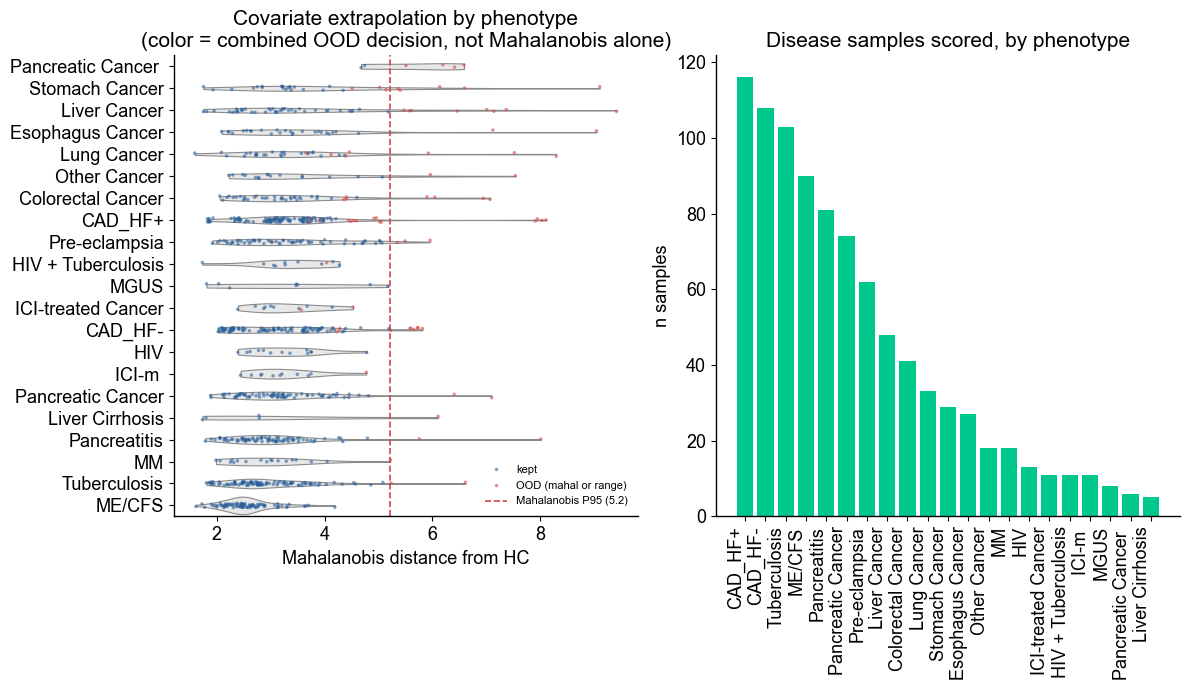

In [8]:
print(f"{summary.shape[0]} phenotypes, {len(phenotype_dis)} disease samples scored")
print(summary[['n_total', 'n_kept']].to_string())

vio = pd.DataFrame({'phenotype': phenotype_dis, 'mahal_dist': mahal_dist, 'n_out': n_out,
                    'flag': np.where(ood_keep, 'kept', 'OOD (mahal or range)')})
order_mahal = vio.groupby('phenotype')['mahal_dist'].mean().sort_values(ascending=False).index
order_count = summary.sort_values('n_total', ascending=False).index

fig, axes = plt.subplots(1, 2, figsize=(12, 7))

# violin shows the Mahalanobis axis, but point color is the COMBINED decision (mahal OR range) --
# a point can sit left of the Mahalanobis line and still be red if the range filter caught it
sns.violinplot(data=vio, y='phenotype', x='mahal_dist', order=order_mahal,
               color='#e8e8e8', orient='h', cut=0, inner=None, linewidth=0.8, ax=axes[0])
sns.stripplot(data=vio, y='phenotype', x='mahal_dist', order=order_mahal, hue='flag',
              hue_order=['kept', 'OOD (mahal or range)'], palette=['#2a6099', '#d64545'],
              orient='h', size=2.5, alpha=0.6, jitter=True, ax=axes[0])
axes[0].axvline(ood.threshold_, color='#d64545', ls='--', lw=1.2, label=f'Mahalanobis P95 ({ood.threshold_:.1f})')
axes[0].set_xlabel('Mahalanobis distance from HC')
axes[0].set_ylabel('')
axes[0].set_title('Covariate extrapolation by phenotype\n(color = combined OOD decision, not Mahalanobis alone)')
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles, labels, frameon=False, fontsize=8, loc='lower right')

axes[1].bar(range(len(order_count)), summary.loc[order_count, 'n_total'], color='#00C78B')
axes[1].set_xticks(range(len(order_count)))
axes[1].set_xticklabels(order_count, rotation=90, ha='right')
axes[1].set_ylabel('n samples')
axes[1].set_title('Disease samples scored, by phenotype')

plt.tight_layout()
fig.savefig(ZDIR / 'phenotype_summary.png', bbox_inches='tight')

In [9]:
# 1. Score (raw RQR) -- cache-first
Z_CAP = 10.0  # |Z| beyond this is already p~1e-23 -- clip only tames the axis, doesn't change BH calls
Z_PATH = ZDIR / 'Z_disease.npy'
GENES_PATH = ZDIR / 'gene_names.pkl'
META_PATH = ZDIR / 'sample_meta.csv'

if Z_PATH.exists():
    Z = np.load(Z_PATH)
else:
    Z = np.clip(engine.score(X_dis, Y_dis, gene_names=gene_names), -Z_CAP, Z_CAP)
    np.save(Z_PATH, Z)
    with open(GENES_PATH, 'wb') as f:
        pickle.dump(gene_names, f)

pd.DataFrame({'sample': names_dis, 'batch': batch_dis, 'phenotype': phenotype_dis,
             'ood_keep': ood_keep, 'mahal_dist': mahal_dist, 'n_out': n_out}).to_csv(META_PATH, index=False)

print(f"Z shape: {Z.shape}, finite frac: {np.isfinite(Z).mean():.4f}, max |Z|: {np.nanmax(np.abs(Z)):.2f}")

Z shape: (913, 19858), finite frac: 1.0000, max |Z|: 5.61


In [10]:
# 2. SHASH-correct -- cache-first
Z_SHASH_PATH = ZDIR / 'Z_disease_shash.npy'

if Z_SHASH_PATH.exists():
    Z_shash = np.load(Z_SHASH_PATH)
else:
    shash_params = load_shash_params(config.CV_MIXED_DIR / 'cv_stats.csv')
    Z_shash = shash_correct_matrix(np.nan_to_num(Z, nan=0.0, posinf=10.0, neginf=-10.0), gene_names, shash_params)
    Z_shash = np.clip(Z_shash, -Z_CAP, Z_CAP)
    Z_shash[~np.isfinite(Z)] = np.nan
    np.save(Z_SHASH_PATH, Z_shash)

print(f"Z_shash shape: {Z_shash.shape}")
print(f"mean |Z| raw vs shash: {np.nanmean(np.abs(Z)):.4f} vs {np.nanmean(np.abs(Z_shash)):.4f}")
print(f"max |Z_shash|: {np.nanmax(np.abs(Z_shash)):.2f}")

Z_shash shape: (913, 19858)
mean |Z| raw vs shash: 0.8521 vs 0.8542
max |Z_shash|: 10.00


In [11]:
from scipy.stats import norm

from MixedEffectsModeling.core.calibration import bh_fdr_reject

N_TOP = 6
FDR_Q = 0.05

# per-sample BH-significant gene count + critical p-value, cache-first
SIG_PATH = ZDIR / 'sample_bh_sig.csv'
if SIG_PATH.exists():
    sig_df = pd.read_csv(SIG_PATH)
else:
    p_all = 2 * norm.sf(np.abs(Z_shash))
    n_sig = np.zeros(len(names_dis), dtype=int)
    p_thr = np.full(len(names_dis), np.nan)
    for i in range(len(names_dis)):
        row = p_all[i]
        row = row[np.isfinite(row)]
        if len(row) == 0:
            continue
        reject = bh_fdr_reject(row, q=FDR_Q)
        n_sig[i] = int(reject.sum())
        if reject.any():
            p_thr[i] = float(row[reject].max())
    sig_df = pd.DataFrame({'sample': names_dis, 'phenotype': phenotype_dis, 'ood_keep': ood_keep,
                           'n_sig': n_sig, 'p_thr': p_thr})
    sig_df.to_csv(SIG_PATH, index=False)

top = sig_df[sig_df['ood_keep']].sort_values('n_sig', ascending=False).head(N_TOP)
print(top[['sample', 'phenotype', 'n_sig', 'p_thr']].to_string(index=False))

     sample         phenotype  n_sig    p_thr
SRR14506728      Liver Cancer   1044 0.002621
SRR14506735      Liver Cancer    689 0.001732
SRR14506802 Colorectal Cancer    574 0.001442
SRR33475188            ICI-m     530 0.001326
SRR14506777    Stomach Cancer    501 0.001258
SRR33475193            ICI-m     498 0.001253


In [12]:
import scanpy as sc

CHROM_ORDER = [f'chr{i}' for i in range(1, 23)] + ['chrX', 'chrY', 'chrM']
chrom_rank = {c: i for i, c in enumerate(CHROM_ORDER)}

var = sc.read_h5ad(config.H5AD_PATH, backed='r').var.loc[gene_names, ['Chromosome']].copy()
var['rank'] = var['Chromosome'].map(chrom_rank).astype(float).fillna(len(CHROM_ORDER))
var = var.sort_values('rank', kind='stable')  # stable: keeps var's own (genomic-proxy) order within a chromosome
var['x'] = range(len(var))

gene_x = var['x'].to_dict()
x_pos = np.array([gene_x[g] for g in gene_names])
chrom_of = var['Chromosome']
tick_df = var.groupby('Chromosome')['x'].median().reindex([c for c in CHROM_ORDER if c in var['Chromosome'].values])
tick_x = tick_df.values
tick_lab = [c.replace('chr', '') for c in tick_df.index]

/tmp/ipykernel_57289/2890160353.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tick_df = var.groupby('Chromosome')['x'].median().reindex([c for c in CHROM_ORDER if c in var['Chromosome'].values])


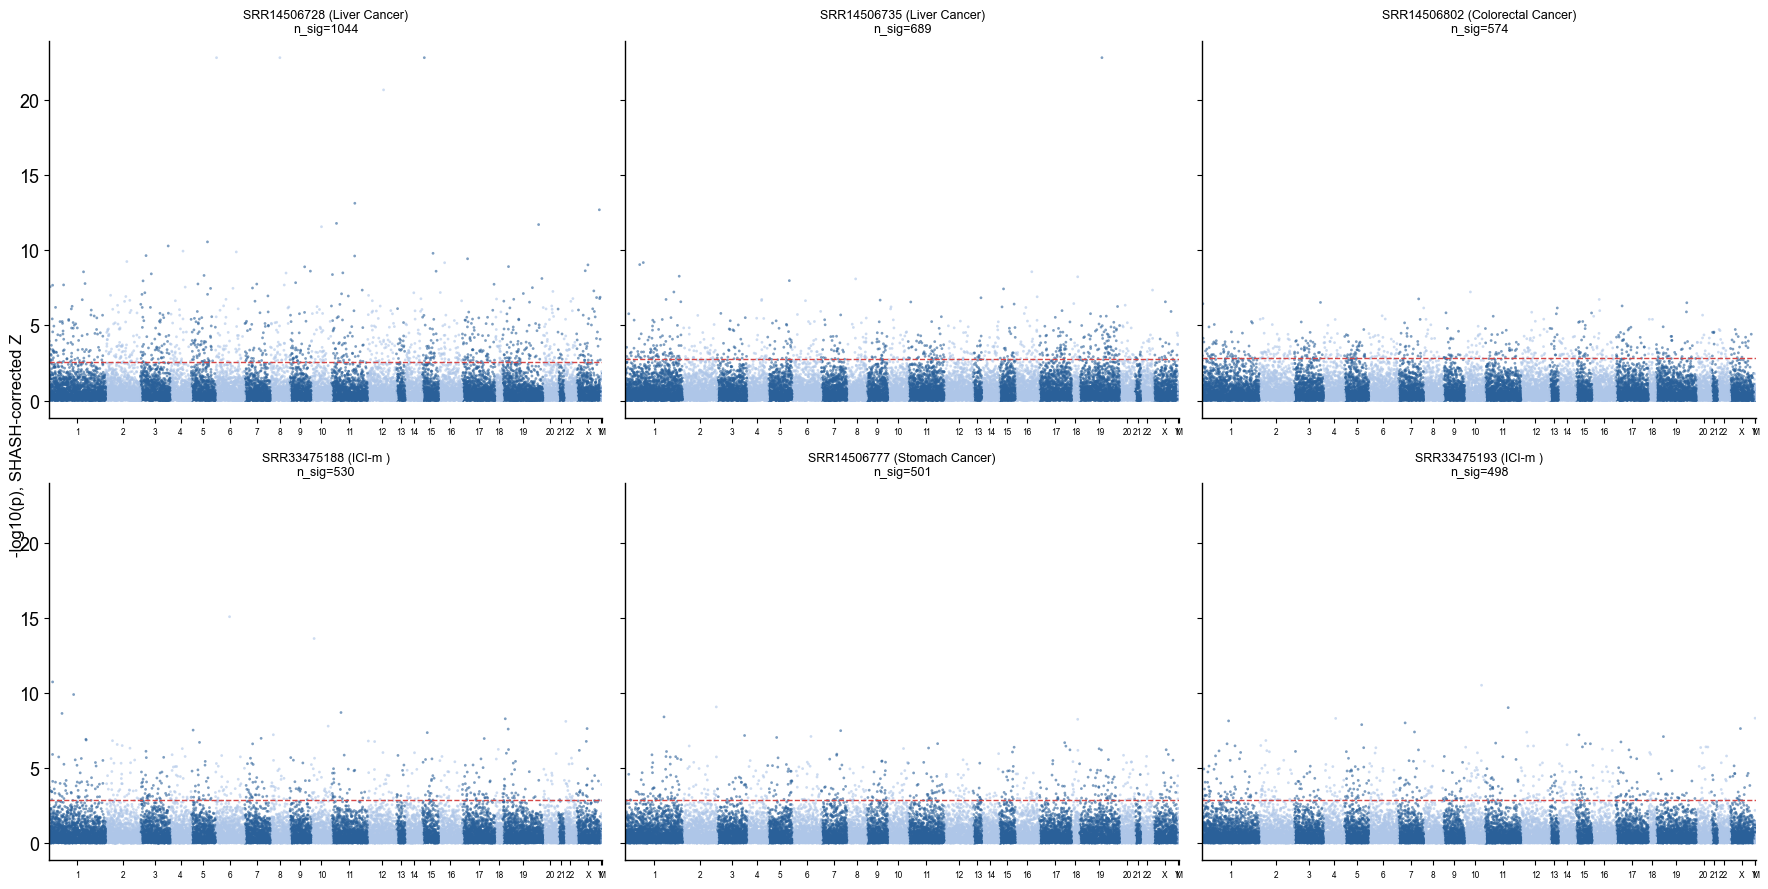

In [13]:
# alternating chromosome colors, index-aligned to gene_names order (= Z_shash columns)
chrom_color = np.where(chrom_of.map(chrom_rank).astype(float).reindex(gene_names).fillna(0).values % 2 == 0, '#2a6099', '#aec6e8')

name2row = {n: i for i, n in enumerate(names_dis)}
n_row = int(np.ceil(N_TOP / 3))
fig, axes = plt.subplots(n_row, 3, figsize=(18, 4.5 * n_row), sharey=True)
axes = np.atleast_1d(axes).flatten()

for ax, (_, row) in zip(axes, top.iterrows()):
    i = name2row[row['sample']]
    z = Z_shash[i]
    p = 2 * norm.sf(np.abs(np.nan_to_num(z)))
    p[~np.isfinite(z)] = np.nan
    neglog10p = -np.log10(np.clip(p, 1e-300, 1))

    ax.scatter(x_pos, neglog10p, c=chrom_color, s=4, alpha=0.6, edgecolors='none')
    if np.isfinite(row['p_thr']):
        ax.axhline(-np.log10(row['p_thr']), color='#d64545', ls='--', lw=1)
    ax.set_xticks(tick_x)
    ax.set_xticklabels(tick_lab, fontsize=6)
    ax.set_title(f"{row['sample']} ({row['phenotype']})\nn_sig={int(row['n_sig'])}", fontsize=9)
    ax.set_xlim(0, len(gene_names))

for ax in axes[len(top):]:
    ax.axis('off')
fig.supylabel('-log10(p), SHASH-corrected Z')
plt.tight_layout()
fig.savefig(ZDIR / 'manhattan_top_samples.png', bbox_inches='tight')

In [14]:
import json

REF_DIR = Path('Benchmark/disease_reference')
MARKER_TOPN = 300
MARKER_SCORE_FLOOR = 0.05

sym_of = sc.read_h5ad(config.H5AD_PATH, backed='r').var['GeneName'].reindex(gene_names)
sym2cols = {}
for j, sym in enumerate(sym_of.values):
    sym2cols.setdefault(sym, []).append(j)

pheno_markers = {}
for f in REF_DIR.glob('*.json'):
    rec = json.load(open(f))
    if rec['phenotype'] == 'MGUS':  # OT association pool too thin (22 genes) for any panel size
        continue
    ranked = sorted(rec['genes'], key=lambda gs: -gs[1])
    floored = [g for g, s in ranked if s >= MARKER_SCORE_FLOOR]
    genes = set(floored[:MARKER_TOPN]) | set(rec.get('supplement', {}).get('genes', []))
    pheno_markers[rec['phenotype']] = genes

p_all = 2 * norm.sf(np.abs(Z_shash))
phenotype_stripped = pd.Series(phenotype_dis).str.strip().values
p_thr_of = sig_df.set_index('sample')['p_thr']
n_sig_of = sig_df.set_index('sample')['n_sig']  # genome-wide BH-significant gene count, not just markers

rows = []
for i, (name, ph) in enumerate(zip(names_dis, phenotype_stripped)):
    markers = pheno_markers.get(ph)
    p_thr = p_thr_of.get(name, np.nan)
    marker_cols = sorted({j for sym in (markers or []) for j in sym2cols.get(sym, [])})
    hit_syms = ([] if not marker_cols or not np.isfinite(p_thr)
                else sorted({sym_of.iloc[j] for j in marker_cols if p_all[i, j] <= p_thr}))
    rows.append((name, ph, ood_keep[i], len(marker_cols), len(hit_syms), ';'.join(hit_syms), int(n_sig_of.get(name, 0))))

marker_df = pd.DataFrame(rows, columns=['sample', 'phenotype', 'ood_keep', 'n_markers_tested',
                                        'n_markers_sig', 'marker_genes_sig', 'n_sig_genome'])
marker_df['frac_markers_sig'] = marker_df['n_markers_sig'] / marker_df['n_markers_tested'].replace(0, np.nan)
marker_df.to_csv(ZDIR / 'sample_marker_hits.csv', index=False)

print(marker_df.groupby('phenotype').agg(
    n_samples=('sample', 'size'), n_markers=('n_markers_tested', 'first'),
    mean_n_sig_genome=('n_sig_genome', 'mean'), mean_frac_sig=('frac_markers_sig', 'mean')).to_string())
marker_df[marker_df['ood_keep'] & (marker_df['n_markers_tested'] > 0)].sort_values(
    'frac_markers_sig', ascending=False).head(15)

                    n_samples  n_markers  mean_n_sig_genome  mean_frac_sig
phenotype                                                                 
CAD_HF+                   116          0          10.034483            NaN
CAD_HF-                   108          0           7.694444            NaN
Colorectal Cancer          41        299         134.682927       0.009707
Esophagus Cancer           27        300          15.888889       0.000494
HIV                        13        300          38.692308       0.001795
HIV + Tuberculosis         11        293           8.454545       0.001241
ICI-m                      11          0         285.454545            NaN
ICI-treated Cancer         11          0          19.909091            NaN
Liver Cancer               48        300         232.520833       0.013472
Liver Cirrhosis             5        300         169.000000       0.005333
Lung Cancer                33        302         194.060606       0.009031
ME/CFS                   

,sample,phenotype,ood_keep,n_markers_tested,n_markers_sig,marker_genes_sig,n_sig_genome,frac_markers_sig
61,SRR14506728,Liver Cancer,True,300,35,ASXL1;ATM;CARD11;CCND1;CREBBP;DDB1;DDX3X;DICER...,1044,0.116667
114,SRR14506802,Colorectal Cancer,True,299,12,BAX;BRCA1;MAFB;MYB;NDRG1;PTEN;RAC1;RPL22;SDHA;...,574,0.040134
585,SRR29803958,Pancreatic Cancer,True,300,9,BCL2;CALR;CUX1;IL7R;KAT6A;MAML2;PTPRC;RSPO3;SF3B1,351,0.030000
113,SRR14506801,Colorectal Cancer,True,299,8,DNMT3A;MTOR;NDRG1;RBM10;RPL22;RXRA;XPA;ZRSR2,368,0.026756
86,SRR14506768,Stomach Cancer,True,300,8,BAP1;CDC73;CIC;LYL1;MSH6;MSI2;PDGFB;RASA1,454,0.026667
42,SRR14506706,Lung Cancer,True,302,8,CARS1;MRTFA;NF2;NSD2;PER1;PRIM2;STK11;ZBTB16,284,0.026490
158,SRR15619011,MM,True,299,7,CDKN2C;CUL4A;HSP90AA1;KDR;POLD4;POT1;WWTR1,285,0.023411
67,SRR14506735,Liver Cancer,True,300,6,ALK;CDKN2A;NTRK1;RECQL4;SSTR3;SSTR4,689,0.020000
250,SRR17333248,Pre-eclampsia,True,296,4,ESAM;MARCKS;NINJ1;PDE4B,217,0.013514
93,SRR14506777,Stomach Cancer,True,300,4,APC;MED12;NSD3;TUBB3,501,0.013333


In [15]:
marker_df

,sample,phenotype,ood_keep,n_markers_tested,n_markers_sig,marker_genes_sig,n_sig_genome,frac_markers_sig
0,SRR14506659,Esophagus Cancer,True,300,0,,4,0.000000
1,SRR14506660,Esophagus Cancer,True,300,1,CBFB,74,0.003333
2,SRR14506661,Esophagus Cancer,True,300,0,,13,0.000000
3,SRR14506663,Esophagus Cancer,False,300,0,,39,0.000000
4,SRR14506665,Esophagus Cancer,True,300,0,,23,0.000000
...,...,...,...,...,...,...,...,...
908,SRR25143502,Pancreatic Cancer,False,300,0,,33,0.000000
909,SRR25143503,Pancreatic Cancer,False,300,1,GNAS,43,0.003333
910,SRR25143504,Pancreatic Cancer,False,300,6,GNAS;MAX;MLH1;MYH9;NCOA2;NRG1,195,0.020000
911,SRR25143505,Pancreatic Cancer,True,300,2,ARID1A;PIK3R1,73,0.006667


In [16]:
from scipy.stats import hypergeom

hc_batch_names = {json.load(open(p))['batch_id'] for p in Path(config.LOBO_MIXED_DIR).glob('*/meta.json')}
batch_of = dict(zip(names_dis, batch_dis))

def enrich_p(row):
    K, n, k = row['n_markers_tested'], row['n_sig_genome'], row['n_markers_sig']
    if n == 0 or k == 0:
        return 1.0
    return hypergeom.sf(k - 1, len(gene_names), K, n)

enrich_df = marker_df[marker_df['ood_keep'] & (marker_df['n_markers_tested'] > 0)].copy()
enrich_df['enrich_p'] = enrich_df.apply(enrich_p, axis=1)
enrich_df['fold_enrich'] = (enrich_df['n_markers_sig'] / enrich_df['n_markers_tested']) / (enrich_df['n_sig_genome'] / len(gene_names))
enrich_df['batch_has_hc'] = enrich_df['sample'].map(batch_of).isin(hc_batch_names)
enrich_df['sig'] = enrich_df['enrich_p'] < 0.05
enrich_df.to_csv(ZDIR / 'sample_marker_enrichment.csv', index=False)

# case-study candidates: significant AND ranked by fold (specificity), not by raw n_sig scale
showcase = enrich_df[enrich_df['sig']].sort_values('fold_enrich', ascending=False)
cols = ['sample', 'phenotype', 'batch_has_hc', 'n_sig_genome', 'n_markers_tested', 'n_markers_sig', 'fold_enrich', 'enrich_p']
print(f"{len(showcase)}/{len(enrich_df)} samples significant (enrich_p<0.05, single a priori test per sample)")
print(showcase[cols].head(20).to_string(index=False))
print()
print(enrich_df.groupby('phenotype').agg(
    n=('sample', 'size'), mean_fold=('fold_enrich', 'mean'), median_fold=('fold_enrich', 'median'),
    n_sig=('sig', 'sum')).to_string())

7/592 samples significant (enrich_p<0.05, single a priori test per sample)
     sample          phenotype  batch_has_hc  n_sig_genome  n_markers_tested  n_markers_sig  fold_enrich  enrich_p
SRR17333242      Pre-eclampsia          True             1               296              1    67.087838  0.014906
SRR29804005       Pancreatitis          True             3               297              1    22.287318  0.044203
SRR28476474 HIV + Tuberculosis          True            20               293              3    10.166212  0.003009
SRR14506833  Colorectal Cancer          True            15               299              2     8.855295  0.020848
SRR14506667   Esophagus Cancer         False            22               300              2     6.017576  0.043077
SRR14506698        Lung Cancer         False            35               302              3     5.636140  0.015916
SRR14506728       Liver Cancer         False          1044               300             35     2.219125  0.000009

    